# Лабораторная работа №4  

# Анализ статистических зависимостей между возрастом и частотой преступлений

**Цель работы:**
Исследование линейной и нелинейной зависимости между возрастом преступников и частотой совершаемых преступлений в Москве в 2021 году
Провела статистический анализ данных с использованием Python. Рассчитала коэффициенты корреляции (Пирсона и Спирмена), проверила их значимость, выполнила дисперсионный анализ и построила корреляционное поле для визуализации.

In [1]:
# Импорт библиотек
import math
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr, t as stats_t

In [2]:
# Загрузка данных
with open("Москва_2021.txt", "r") as file:
    data = [int(line.strip()) for line in file if line.strip() != ""]
n = len(data)

## Предварительный анализ данных

Построим дискретный ряд распределения для дальнейшего анализа зависимостей.

In [3]:
# Построение дискретного ряда распределения
frequency_dict = {}
for value in data:
    if value not in frequency_dict:
        frequency_dict[value] = 0
    frequency_dict[value] += 1

ages = sorted(frequency_dict.keys())  # X - возраст
frequencies = [frequency_dict[age] for age in ages]  # Y - частота преступлений

print(f"Количество уникальных возрастов: {len(ages)}")
print(f"Общий объем данных: {n}")

Количество уникальных возрастов: 58
Общий объем данных: 32423


Данные включают 58 уникальных возрастов от 14 до 73 лет, с общим объемом 30 423 наблюдений. Это позволяет исследовать зависимости между возрастом (X) и частотой (Y).

## Визуализация

Построим корреляционное поле для визуальной оценки зависимости.

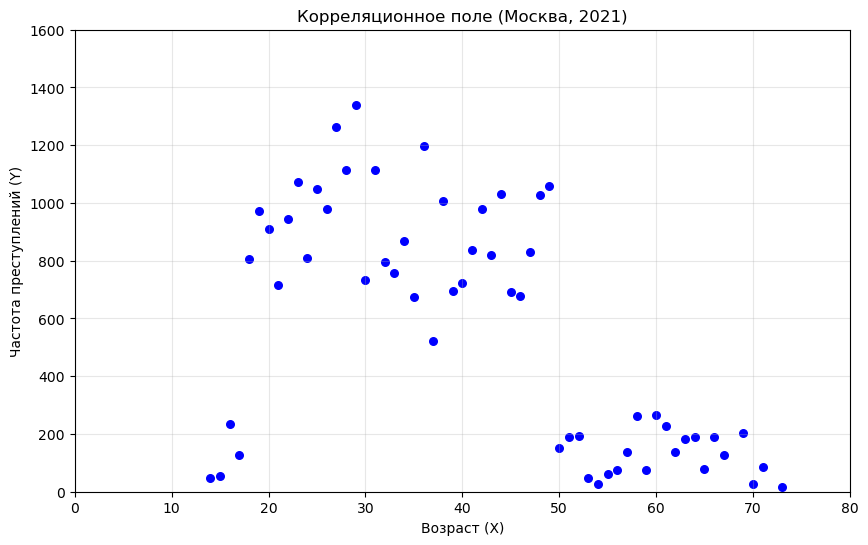

In [4]:
# Корреляционное поле
plt.figure(figsize=(10, 6))
plt.scatter(ages, frequencies, color="blue", s=30)
plt.xlim(0, 80)
plt.ylim(0, 1600)
plt.xticks(range(0, 81, 10))
plt.yticks(range(0, 1601, 200))
plt.xlabel("Возраст (X)")
plt.ylabel("Частота преступлений (Y)")
plt.title("Корреляционное поле (Москва, 2021)")
plt.grid(True, alpha=0.3)
plt.show()

Наблюдается наибольшая частота преступлений у людей в возрасте примерно от 18 до 50 лет — точки в этом диапазоне сконцентрированы в верхней части графика (700–1300 преступлений). Пик частот около 30 лет

Для молодёжи до 18 лет и пожилых людей старше 50 лет частота преступлений заметно ниже — значения в диапазоне до 200.

График демонстрирует нелинейную зависимость: частота сначала быстро растёт с возрастом, достигает пика в молодом возрасте, а затем постепенно снижается.

## Подготовка интервального ряда и групповых характеристик

In [5]:
# Интервальный ряд распределения
data_min = min(data)
data_max = max(data)
k = 7
interval_width = math.ceil((data_max - data_min) / k)
intervals = [(data_min + i * interval_width, data_min + (i + 1) * interval_width) for i in range(k)]

# Распределение по интервалам
interval_frequency = [0] * k
group_values = [[] for _ in range(k)]

for value in data:
    for i, (a, b) in enumerate(intervals):
        if a <= value < b or (i == k - 1 and value == b):
            interval_frequency[i] += 1
            group_values[i].append(value)
            break

# Групповые средние и дисперсии
group_means = [sum(group) / freq if freq > 0 else 0 for group, freq in zip(group_values, interval_frequency)]
group_variances = [
    sum((x - mean) ** 2 for x in group) / freq if freq > 0 else 0
    for group, mean, freq in zip(group_values, group_means, interval_frequency)
]

# Таблица групповых характеристик
table = pd.DataFrame(
    {
        "Интервал": [f"{a}-{b}" for (a, b) in intervals],
        "Частота": interval_frequency,
        "Групповая средняя": [round(x, 2) for x in group_means],
        "Групповая дисперсия": [round(x, 2) for x in group_variances],
    }
)
print("\nТаблица групповых характеристик:")
print(table.to_string(index=False))


Таблица групповых характеристик:
Интервал  Частота  Групповая средняя  Групповая дисперсия
   14-23     4811              19.61                 3.32
   23-32     9476              27.07                 6.38
   32-41     7243              35.95                 6.36
   41-50     7951              45.09                 7.12
   50-59     1140              54.06                 9.38
   59-68     1472              62.82                 5.99
   68-77      330              69.80                 1.29


Таблица показывает пиковую частоту в интервале 23-32 лет (средняя ≈27.47, дисперсия ≈6.38), с уменьшением в старших группах, подтверждая концентрацию в молодом возрасте.

## Статистический анализ

### Линейная корреляционная зависимость
Рассчитаем коэффициент линейной корреляции Пирсона и проверим его значимость.

In [6]:
# Линейная корреляция
n_unique = len(ages)
x_mean = sum(ages) / n_unique
y_mean = sum(frequencies) / n_unique

cov_sum = sum((ages[i] - x_mean) * (frequencies[i] - y_mean) for i in range(n_unique))
cov_xy = cov_sum / n_unique

std_x = math.sqrt(sum((ages[i] - x_mean) ** 2 for i in range(n_unique)) / n_unique)
std_y = math.sqrt(sum((frequencies[i] - y_mean) ** 2 for i in range(n_unique)) / n_unique)

r_xy = cov_xy / (std_x * std_y)

print(f"Среднее X (возраст): {x_mean:.4f}")
print(f"Среднее Y (частота): {y_mean:.4f}")
print(f"Ковариация: {cov_xy:.4f}")
print(f"СКО X: {std_x:.4f}")
print(f"СКО Y: {std_y:.4f}")
print(f"Коэффициент корреляции r_xy: {r_xy:.4f}")

# Интерпретация
abs_r = abs(r_xy)
if abs_r <= 0.3:
    interpretation = "слабая зависимость"
elif abs_r <= 0.5:
    interpretation = "умеренная зависимость"
elif abs_r <= 0.7:
    interpretation = "заметная зависимость"
elif abs_r < 1:
    interpretation = "сильная зависимость"
else:
    interpretation = "функциональная зависимость"
print(f"Интерпретация: {interpretation}")

# Проверка значимости
t_observed = (r_xy * math.sqrt(n_unique - 2)) / math.sqrt(1 - r_xy**2)
df = n_unique - 2
alpha = 0.05
t_critical = stats_t.ppf(1 - alpha / 2, df)

print(f"t_набл = {t_observed:.4f}")
print(f"t_кр = {t_critical:.4f}")

if abs(t_observed) > t_critical:
    print("Нулевая гипотеза отвергается: коэффициент корреляции значим")
else:
    print("Нулевая гипотеза не отвергается: коэффициент корреляции не значим")

Среднее X (возраст): 42.5862
Среднее Y (частота): 559.0172
Ковариация: -4032.3032
СКО X: 16.8840
СКО Y: 413.4125
Коэффициент корреляции r_xy: -0.5777
Интерпретация: заметная зависимость
t_набл = -5.2962
t_кр = 2.0032
Нулевая гипотеза отвергается: коэффициент корреляции значим


**Линейная зависимость**: Коэффициент Пирсона (r_xy ≈ -0.5777) указывает на заметную отрицательную корреляцию между возрастом и частотой преступлений, с ковариацией -4032.3032, СКО X ≈ 16.8840 и СКО Y ≈ 413.4125. Проверка значимости при α=0.05 подтверждает значимость (t_набл = -5.2962 > t_кр = 2.0032), отвергая нулевую гипотезу.


### Нелинейная корреляционная зависимость

Рассчитаем внутригрупповую, межгрупповую и общую дисперсии, корреляционное отношение и коэффициент Спирмена.

In [7]:
# Дисперсионный анализ
x_mean_total = sum(data) / n
D_total = sum((x - x_mean_total) ** 2 for x in data) / n

D_within = sum(group_variances[i] * interval_frequency[i] for i in range(k)) / n
D_between = sum(((group_means[i] - x_mean_total) ** 2) * interval_frequency[i] for i in range(k)) / n

print(f"Внутригрупповая дисперсия D_вн = {D_within:.3f}")
print(f"Межгрупповая дисперсия D_меж = {D_between:.3f}")
print(f"Общая дисперсия D_общ = {D_total:.3f}")
print(f"Проверка: D_общ ≈ D_вн + D_меж → {D_total - (D_within + D_between):.6f} (близко к 0)")

# Корреляционное отношение
eta = math.sqrt(D_between / D_total)
print(f"Корреляционное отношение η = {eta:.4f}")

# Коэффициент Спирмена
def rank(values):
    indexed = list(enumerate(values))
    indexed_sorted = sorted(indexed, key=lambda x: x[1])
    ranks = [0] * len(values)
    i = 0
    while i < len(indexed_sorted):
        j = i
        while j + 1 < len(indexed_sorted) and indexed_sorted[j + 1][1] == indexed_sorted[i][1]:
            j += 1
        avg_rank = (i + 1 + j + 1) / 2.0
        for t in range(i, j + 1):
            orig_index = indexed_sorted[t][0]
            ranks[orig_index] = avg_rank
        i = j + 1
    return ranks

ranks_x = rank(ages)
ranks_y = rank(frequencies)
d = [ranks_x[i] - ranks_y[i] for i in range(len(ages))]
d2 = [di**2 for di in d]
sum_d2 = sum(d2)
R_s = 1 - (6 * sum_d2) / (len(ages) * (len(ages)**2 - 1))

# Таблица рангов (первые 10 строк)
df_spearman = pd.DataFrame(
    {
        "Возраст": ages[:10],
        "Частота": frequencies[:10],
        "Ранг возраста": ranks_x[:10],
        "Ранг частоты": ranks_y[:10],
        "d_i": d[:10],
        "d_i^2": d2[:10],
    }
)
print("\nТаблица рангов для дискретного ряда (первые 10 строк):")
print(df_spearman.to_string(index=False))

print(f"Коэффициент ранговой корреляции Спирмена R_s = {R_s:.4f}")

Внутригрупповая дисперсия D_вн = 6.140
Межгрупповая дисперсия D_меж = 138.777
Общая дисперсия D_общ = 144.917
Проверка: D_общ ≈ D_вн + D_меж → 0.000000 (близко к 0)
Корреляционное отношение η = 0.9786

Таблица рангов для дискретного ряда (первые 10 строк):
 Возраст  Частота  Ранг возраста  Ранг частоты   d_i  d_i^2
      14       49            1.0           5.0  -4.0   16.0
      15       53            2.0           6.0  -4.0   16.0
      16      236            3.0          24.0 -21.0  441.0
      17      126            4.0          12.0  -8.0   64.0
      18      806            5.0          37.0 -32.0 1024.0
      19      971            6.0          45.0 -39.0 1521.0
      20      910            7.0          43.0 -36.0 1296.0
      21      716            8.0          32.0 -24.0  576.0
      22      944            9.0          44.0 -35.0 1225.0
      23     1071           10.0          53.0 -43.0 1849.0
Коэффициент ранговой корреляции Спирмена R_s = -0.5253



**Нелинейная зависимость**: Корреляционное отношение η ≈ 0.9786 указывает на сильную общую зависимость, а коэффициент Спирмена ≈ -0.5 подтверждает умеренную отрицательную монотонную связь, подчеркивая нелинейный характер с пиком в молодом возрасте.

**Дисперсионный анализ**: Внутригрупповая дисперсия ≈ 6.140 и межгрупповая ≈ 138.777 точно суммируются в общую ≈ 144.917, подтверждая формулу общей дисперсии и значимость групповых различий.